In [24]:
"""
Do we want 1 or 4 Vpp for new sensors?

4 Vpp allows a higher dynamic range of sensor, reducing issues of saturation.
However, bin width increases by a factor of four.

What is the probability of saturation events making a TGF measurement mostly useless versus the
impact of lower bit precision on spectrum estimation. Saturation events are less impactful the more
events we capture because the marginal value of "good" measurements will decrease with increasing data.
How much "more" of the spectrum would 4Vpp let us capture? Ofc, pileup also causes increased voltage...

On the other hand... due to power law spectrum, higher energy photons have higher marginal value for estimating spectrum...
Is it better to capture lower energy spectrum with more accuracy or higher energy spectrum

P(saturation) <- spectrum (Multiple from different event types?),
              <- count rate <- distance (we dont know altitudes they occur which is the toughest part)

We should tune the electronics response to be have a short FWHM. Energy precision is less important than reducing pileup.

Why does the PLA sensor have two poles but the NAI has one?
How much "more" of the spectrum would 4 Vpp let us capture? (low count rate)

If we view the system as a harmonic oscillator, does that itself invalidate the assumption of linear response to multiple
scaled unit impulses? Still linear right...? we could write a quick ODE test of this... Possible it works for Over/Critically but not under-damped systems?

Generate up-sampled response via spline interpolation for downsampling! This also lets us test "real" time discretiazation impacts

How much THOR data do we really have? Was that ground based data? I am trying to figure out how likely we might be to see
photons of certain energies (very roughly, I know the total TGF radiated energy is an open problem) versus pileup. The issue
is the relationship between them.

Could we make a characterize HERA from responses to cosmic muons?
Impact of increased bit width on THOR? Test HERA simulations at low count rate using THOR magnitudes ~ roughly?

how high are the bottoms of clouds? (for weather of interest? How much does this vary?)
how high do the planes fly (C130s?)
Distance should affect countrate much more strongly than energies measured!!!!

In general it would be great to take a "monoenergetic source" and place it at different distances from HERA.
We could do a few different such sources
Want to test different true energy magnitudes. Want to test different pileups and saturation
Would also be nice to test different gains.


Check out https://en.wikipedia.org/wiki/Log_amplifier
https://ieeexplore.ieee.org/document/8096303
https://www.monolithicpower.com/en/learning/mpscholar/analog-to-digital-converters/future-trends-and-challenges-in-adcs/novel-adc-architectures?srsltid=AfmBOop9VzN5yjNmWUbFwj4Scbbde160cfq910SjwQlERqAeBcNfJtkh
https://www.researchgate.net/publication/224169632_A_64_Channel_Programmable_Closed-Loop_Neurostimulator_With_8_Channel_Neural_Amplifier_and_Logarithmic_ADC/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6Il9kaXJlY3QiLCJwYWdlIjoiX2RpcmVjdCJ9fQ
https://www.analog.com/en/resources/technical-articles/integrated-dc-logarithmic-amplifiers.html
Also, checkout out radar electronics. Radar also has huge signal dynmaic range and high sampling rates...

https://www.digikey.com/en/products/filter/analog-to-digital-converters-adc/700?s=N4IgjCBcoMwCwA4qgMZQGYEMA2BnApgDQgD2UA2uAGwDsAnDBMQKzNgJ0gs1x1xchmABjo0qAsACYhYGRMZUqSYmHhU4k%2BXHUwB0sHSq6VNSXWaaTZ5sfA1TfPZJqsmISYjgWQAXWIAHABcoEABlQIAnAEsAOwBzEABfYgBaTWgQNEhIgFciUgpBX0Tk90LMABM0H0SgA


"""


'\nDo we want 1 or 4 Vpp for new sensors?\n\n4 Vpp allows a higher dynamic range of sensor, reducing issues of saturation.\nHowever, bin width increases by a factor of four.\n\nWhat is the probability of saturation events making a TGF measurement mostly useless versus the\nimpact of lower bit precision on spectrum estimation. Saturation events are less impactful the more\nevents we capture because the marginal value of "good" measurements will decrease with increasing data.\nHow much "more" of the spectrum would 4Vpp let us capture? Ofc, pileup also causes increased voltage...\n\nOn the other hand... due to power law spectrum, higher energy photons have higher marginal value for estimating spectrum...\nIs it better to capture lower energy spectrum with more accuracy or higher energy spectrum\n\nP(saturation) <- spectrum (Multiple from different event types?),\n              <- count rate <- distance (we dont know altitudes they occur which is the toughest part)\n\nWe should tune the el

In [25]:
"""
Need to investigate pileup and saturation? Using sim data (ignoring the THOR issue)
How much faster does pileup degrade error? Relative impact vs saturation?

Plan for this analysis:

for countrate in countrates:
    generate trace
    NNLSR(trace)
    
    metrics
        error per bin?
        % photons counted?
        % energy counted?
        
Analysis:
    if metric per countrate is scalar: plot(countrate, metric)
    if metric per countrate is vector: loop : plot(countrate, metric vector)
    
    
Repeat with Short response (just ignore 1V ceiling and we can look at improvements to pileup.. behavior...

"""

'\nNeed to investigate pileup and saturation? Using sim data (ignoring the THOR issue)\nHow much faster does pileup degrade error? Relative impact vs saturation?\n\nPlan for this analysis:\n\nfor countrate in countrates:\n    generate trace\n    NNLSR(trace)\n    \n    metrics\n        error per bin?\n        % photons counted?\n        % energy counted?\n        \nAnalysis:\n    if metric per countrate is scalar: plot(countrate, metric)\n    if metric per countrate is vector: loop : plot(countrate, metric vector)\n    \n    \nRepeat with Short response (just ignore 1V ceiling and we can look at improvements to pileup.. behavior...\n\n'

In [26]:
import numpy as np
import numpy.random as ran
import matplotlib.pyplot as plt
import pylab as pl
import pandas as pd
import scipy
import time
from matplotlib import rcParams
from util.Processing import *
from util.DataGen import *

In [27]:
countrates = np.logspace(5, 8, 7)

In [28]:
#variables for creating the trace
fwhm = 10 #50.0 
TGF_duration = fwhm*3e-6
# counts = int(countrate*TGF_duration) #total counts incident on the detector   
#fwhm = 50.0 #fwhm of the total TGF count distribution in units microseconds
#TGF_duration = fwhm*3e-6 #this is a really rough estimate to get a rough estimate of the count rate
#countrate = int(counts/TGF_duration)
mean = .7 #mean of the TGF trace distribution
std = .5 #detemines the amount of asymetry in the TGF trace distribution
dt = 1e-9 # seconds before pulse
tstep = 25e-9 #sampling rate in seconds. 40MHz
trace_length = 28000 #number of samples in a trace file (700us at 40MHz)
keV_per_area = .147 #determined by trial and error to match energy range of instrument 
mV_per_ADC = 1000./4096.
specscale_keV = 5.0  #spectrum scaling i.e. keV/line in the spectrum file
baseline = 110
basenoise = 0 #units mV
bits = 16  #use 12 for doing listmode but use 10 to compare traces to real trace files

#variables for integrating trace pulses into listmode events
thresh = 8.0     #units of mV  this is the pulse trigger threshold
int_i = 50      #integ.ration time = 1.25 microsecs = 50 samples at 40MHz sampling 
dead_i = int_i     #deadtime = integration time
extend = 1    #extendable dead time parameter
escale = .63  #being used to scale the pulse integration value to energy in keV. experimentally determined.

#example spectrum of TGF energy deposit in a detector
NaI_Response = np.loadtxt('../original/NaI_Response',usecols=(1),dtype=float)
bins = np.loadtxt('../original/NaI_Response',usecols=(0),dtype=float)
#s = np.genfromtxt('/home/enp//Desktop/Emorpho Analysis Software and Calibration data/Emorpho Simulations/alt5SFT_noaa_plane_rough.out', usecols = (2), skip_footer=2)

spectrum = NaI_Response
binenergies = bins*1e3 #units keV 
#spectrum[49]= 2000 #49 is 1000keV, 85 is 6800keV

#real NaI trace example data
tracedata = pd.read_csv('../original/real_nai_trace.csv')

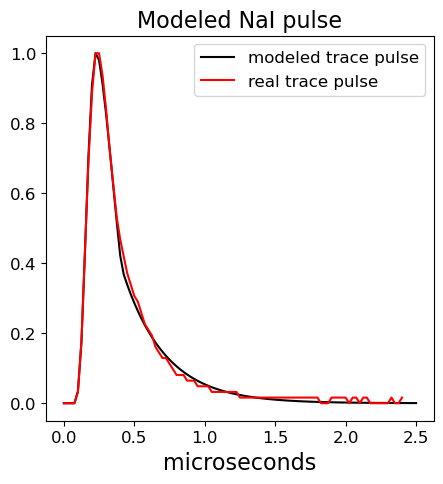

In [29]:
#calling the sample trace pulse and real trace data
pulsetimes,pulse = nai_pulse(1.)
nsamples = len(pulse)
tdatatime = tracedata.Seconds[253:350]-tracedata.Seconds[253]
tdata = (tracedata.Tracesample[253:350]-27)/(max(tracedata.Tracesample)-27)

# fit single trace plot 
plt.figure(figsize=(5,5))
plt.plot(pulsetimes*1e6,pulse,color='black',label='modeled trace pulse')
#plt.scatter(tdatatime,tdata)
#plt.scatter(pulsetimes,pulse)
plt.plot(tdatatime*1e6,tdata,color='red',label='real trace pulse')
plt.xlabel('microseconds',fontsize=16)
plt.title('Modeled NaI pulse',fontsize=16)
#plt.xlim(-.5e-6,3.0e-6)
plt.tick_params(labelsize=12)
plt.legend(fontsize=12)

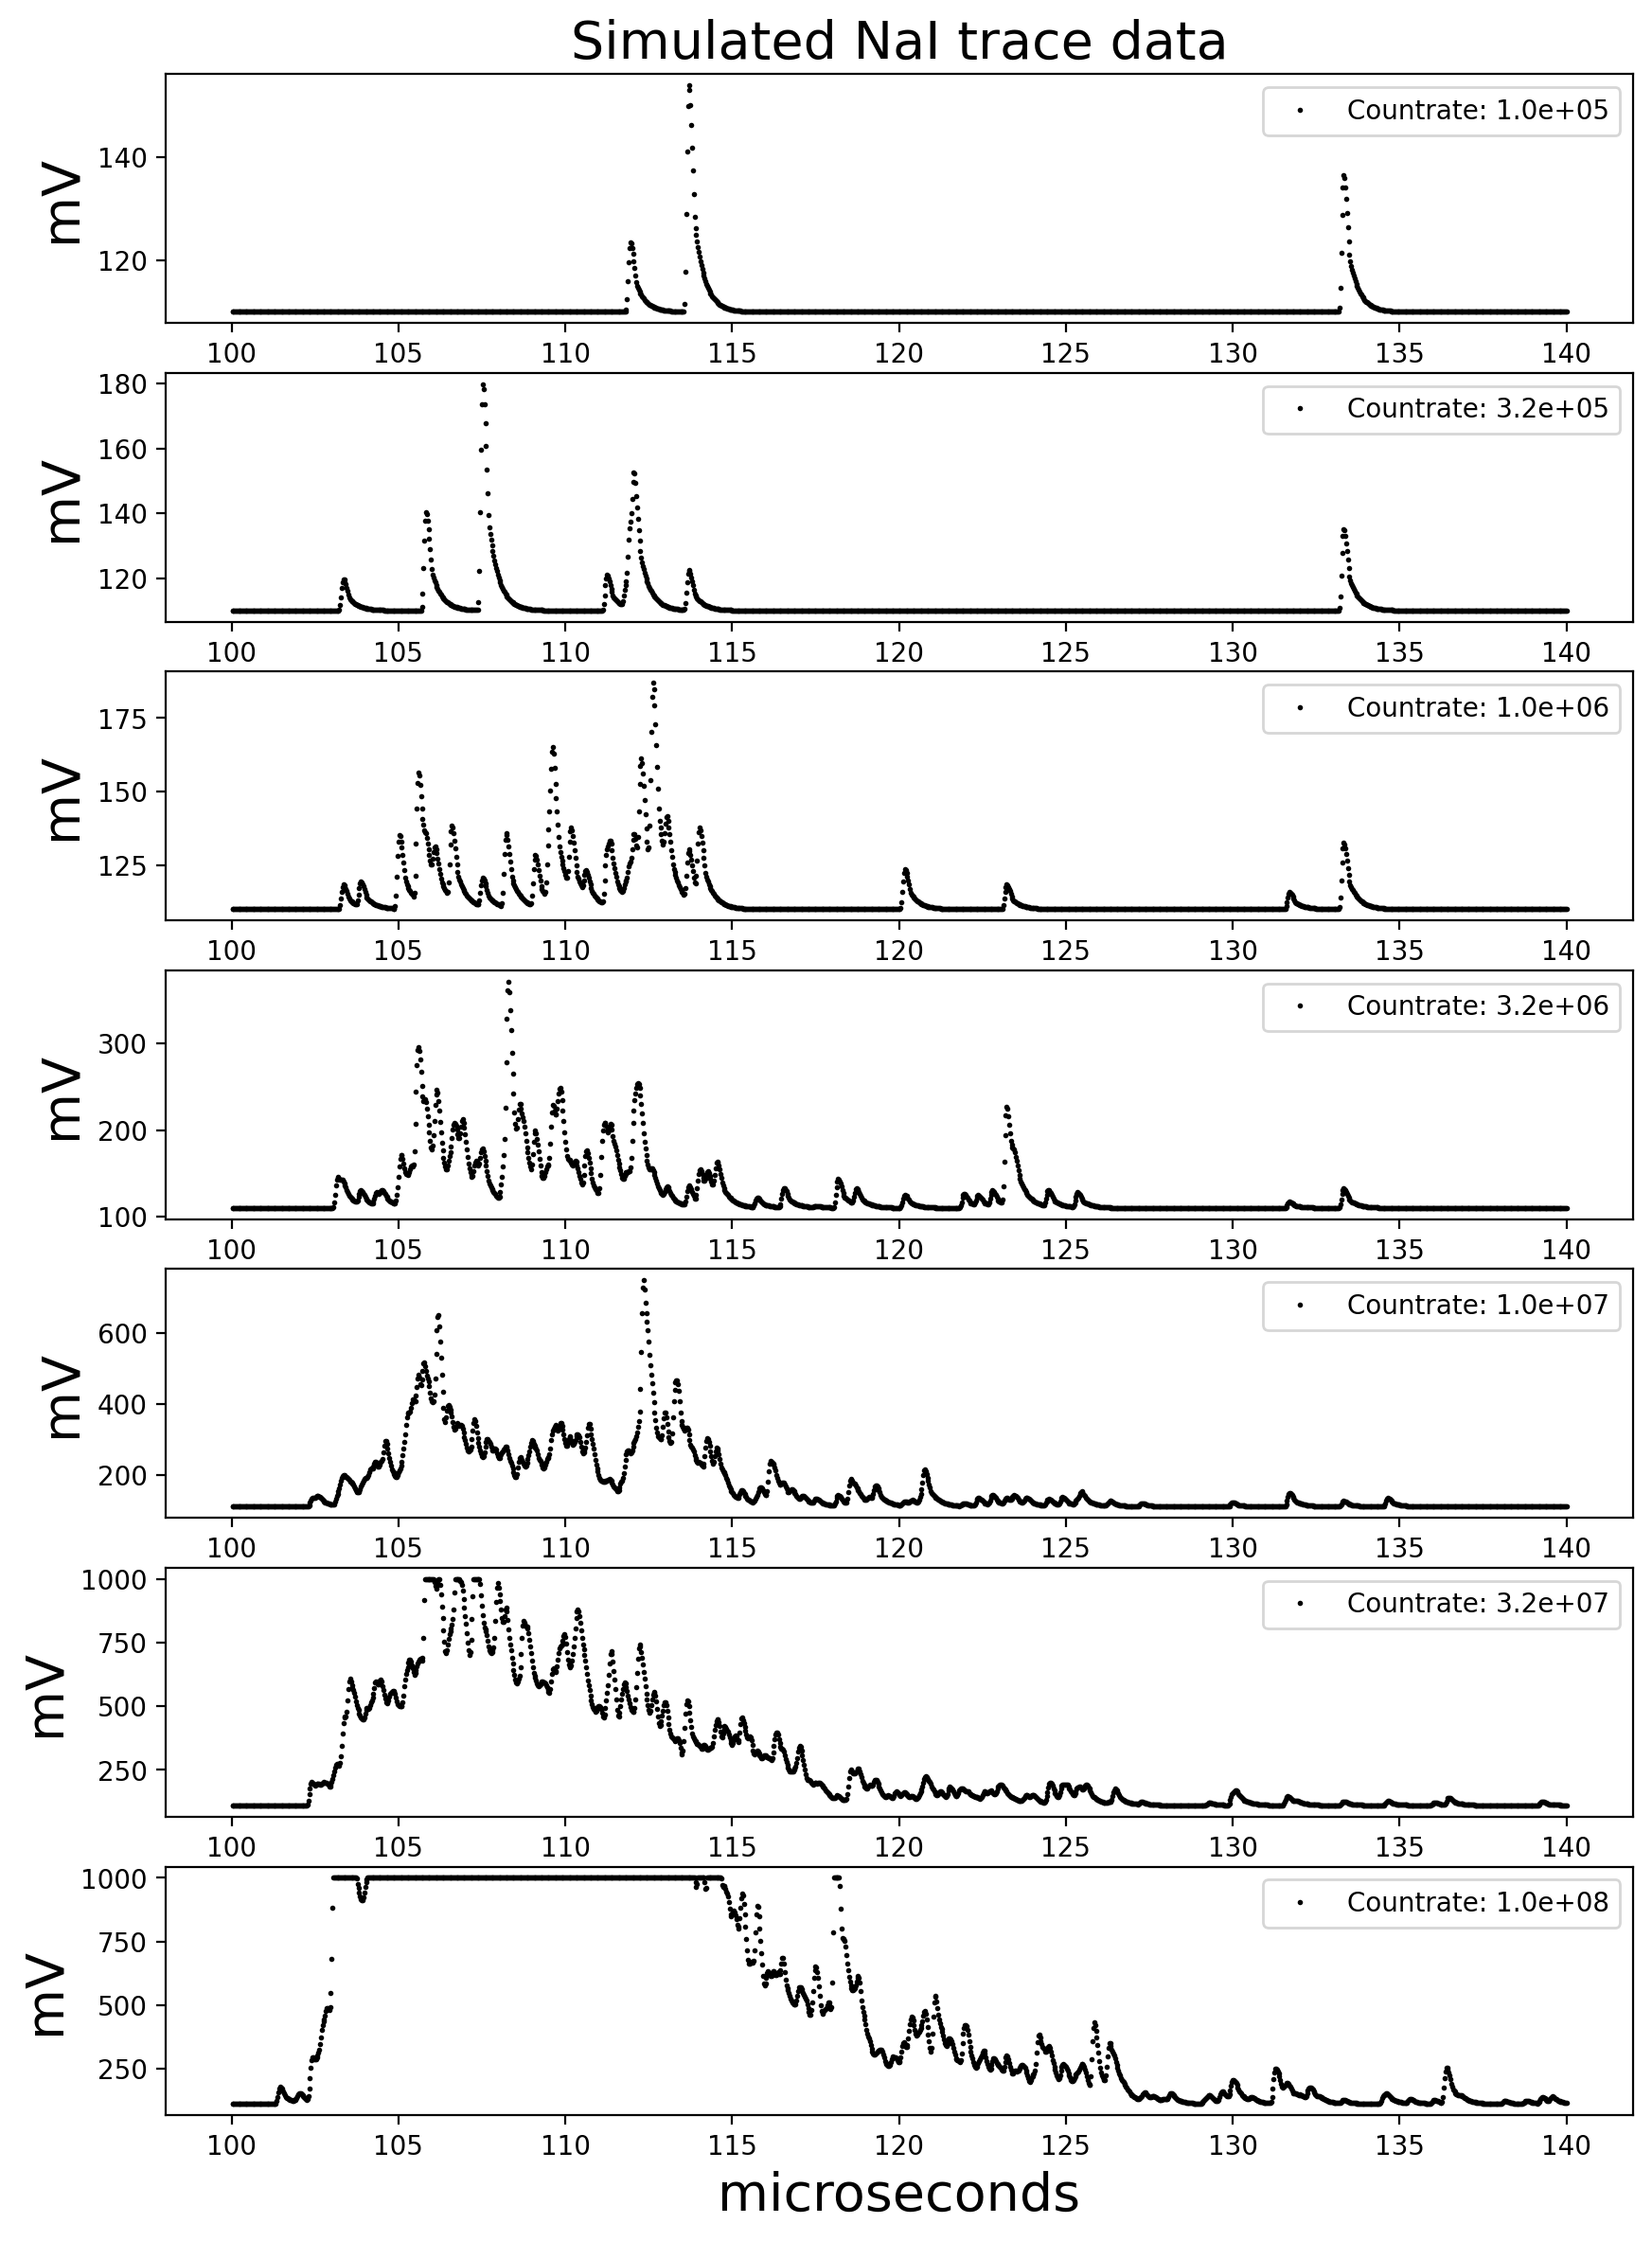

In [30]:
traces = []
triggers = []
truth = []

# countrates = np.array([1E5, 1E5])

for countrate in countrates:
    counts = int(countrate*TGF_duration) #total counts incident on the detector
    
    # Build trace and find trigger time
    trace_time, trace, photon_index, energies, peak_volts = lognormal_nai_trace(counts, fwhm, spectrum,binenergies, dt, tstep,
                                                                         trace_length, mV_per_ADC, keV_per_area, specscale_keV,
                                                                         baseline, basenoise, bits,mean,std)
    # print(photon_index, trace_time[photon_index], trace.size)
    
    trace_time *= 1E6 # convert to microseconds    
    trigger_time, trigger_index = trace_trigger(trace, trace_time)
    
    # Get Trace slice with significant activity
    lower = 100
    upper = 140
    mask = np.logical_and(lower <= trace_time, trace_time <= upper)
    trace_slice = trace[mask]
    trace_time_slice = trace_time[mask]
    
    # print(photon_index)
    # lower and upper by index
    # print(np.nonzero(lower <= trace_time)[0][0], np.nonzero(trace_time <= upper)[0][-1])
    lower = np.nonzero(lower <= trace_time)[0][0] #first
    upper = np.nonzero(trace_time <= upper)[0][-1] # last
    mask = np.logical_and(lower <= photon_index, photon_index <= upper)
    energies = energies[mask]
    peak_volts = peak_volts[mask]
    photon_index = photon_index[mask] - lower
    
    
    # append data to associated lists
    traces.append((trace_time_slice, trace_slice))
    triggers.append((trigger_time, trigger_index))
    truth.append((photon_index, energies, peak_volts))

    
n = countrates.size
fig, axes = plt.subplots(n, 1, figsize=(10, n*2), dpi=200)
for axis, trace_pair, trigger_pair, countrate in zip(axes, traces, triggers, countrates):
    trace_time, trace = trace_pair
    trigger_time, trigger_index = trigger_pair
    
    axis.plot(trace_time, trace,color='black', marker='.', markersize=2, linestyle='', label='Countrate: {:.1e}'.format(countrate))
    # axis.set_xlim(100,300)
    axis.set_ylabel('mV',fontsize=20)
    axis.legend()
    
    if axis == axes[0]:
        axis.set_title('Simulated NaI trace data',fontsize=20)
    if axis == axes[-1]:
        axis.set_xlabel('microseconds',fontsize=20)
    
    # if trigger_time.size > 0:
    #     axis.vlines(trigger_time,110,max(trace),color='red')
    


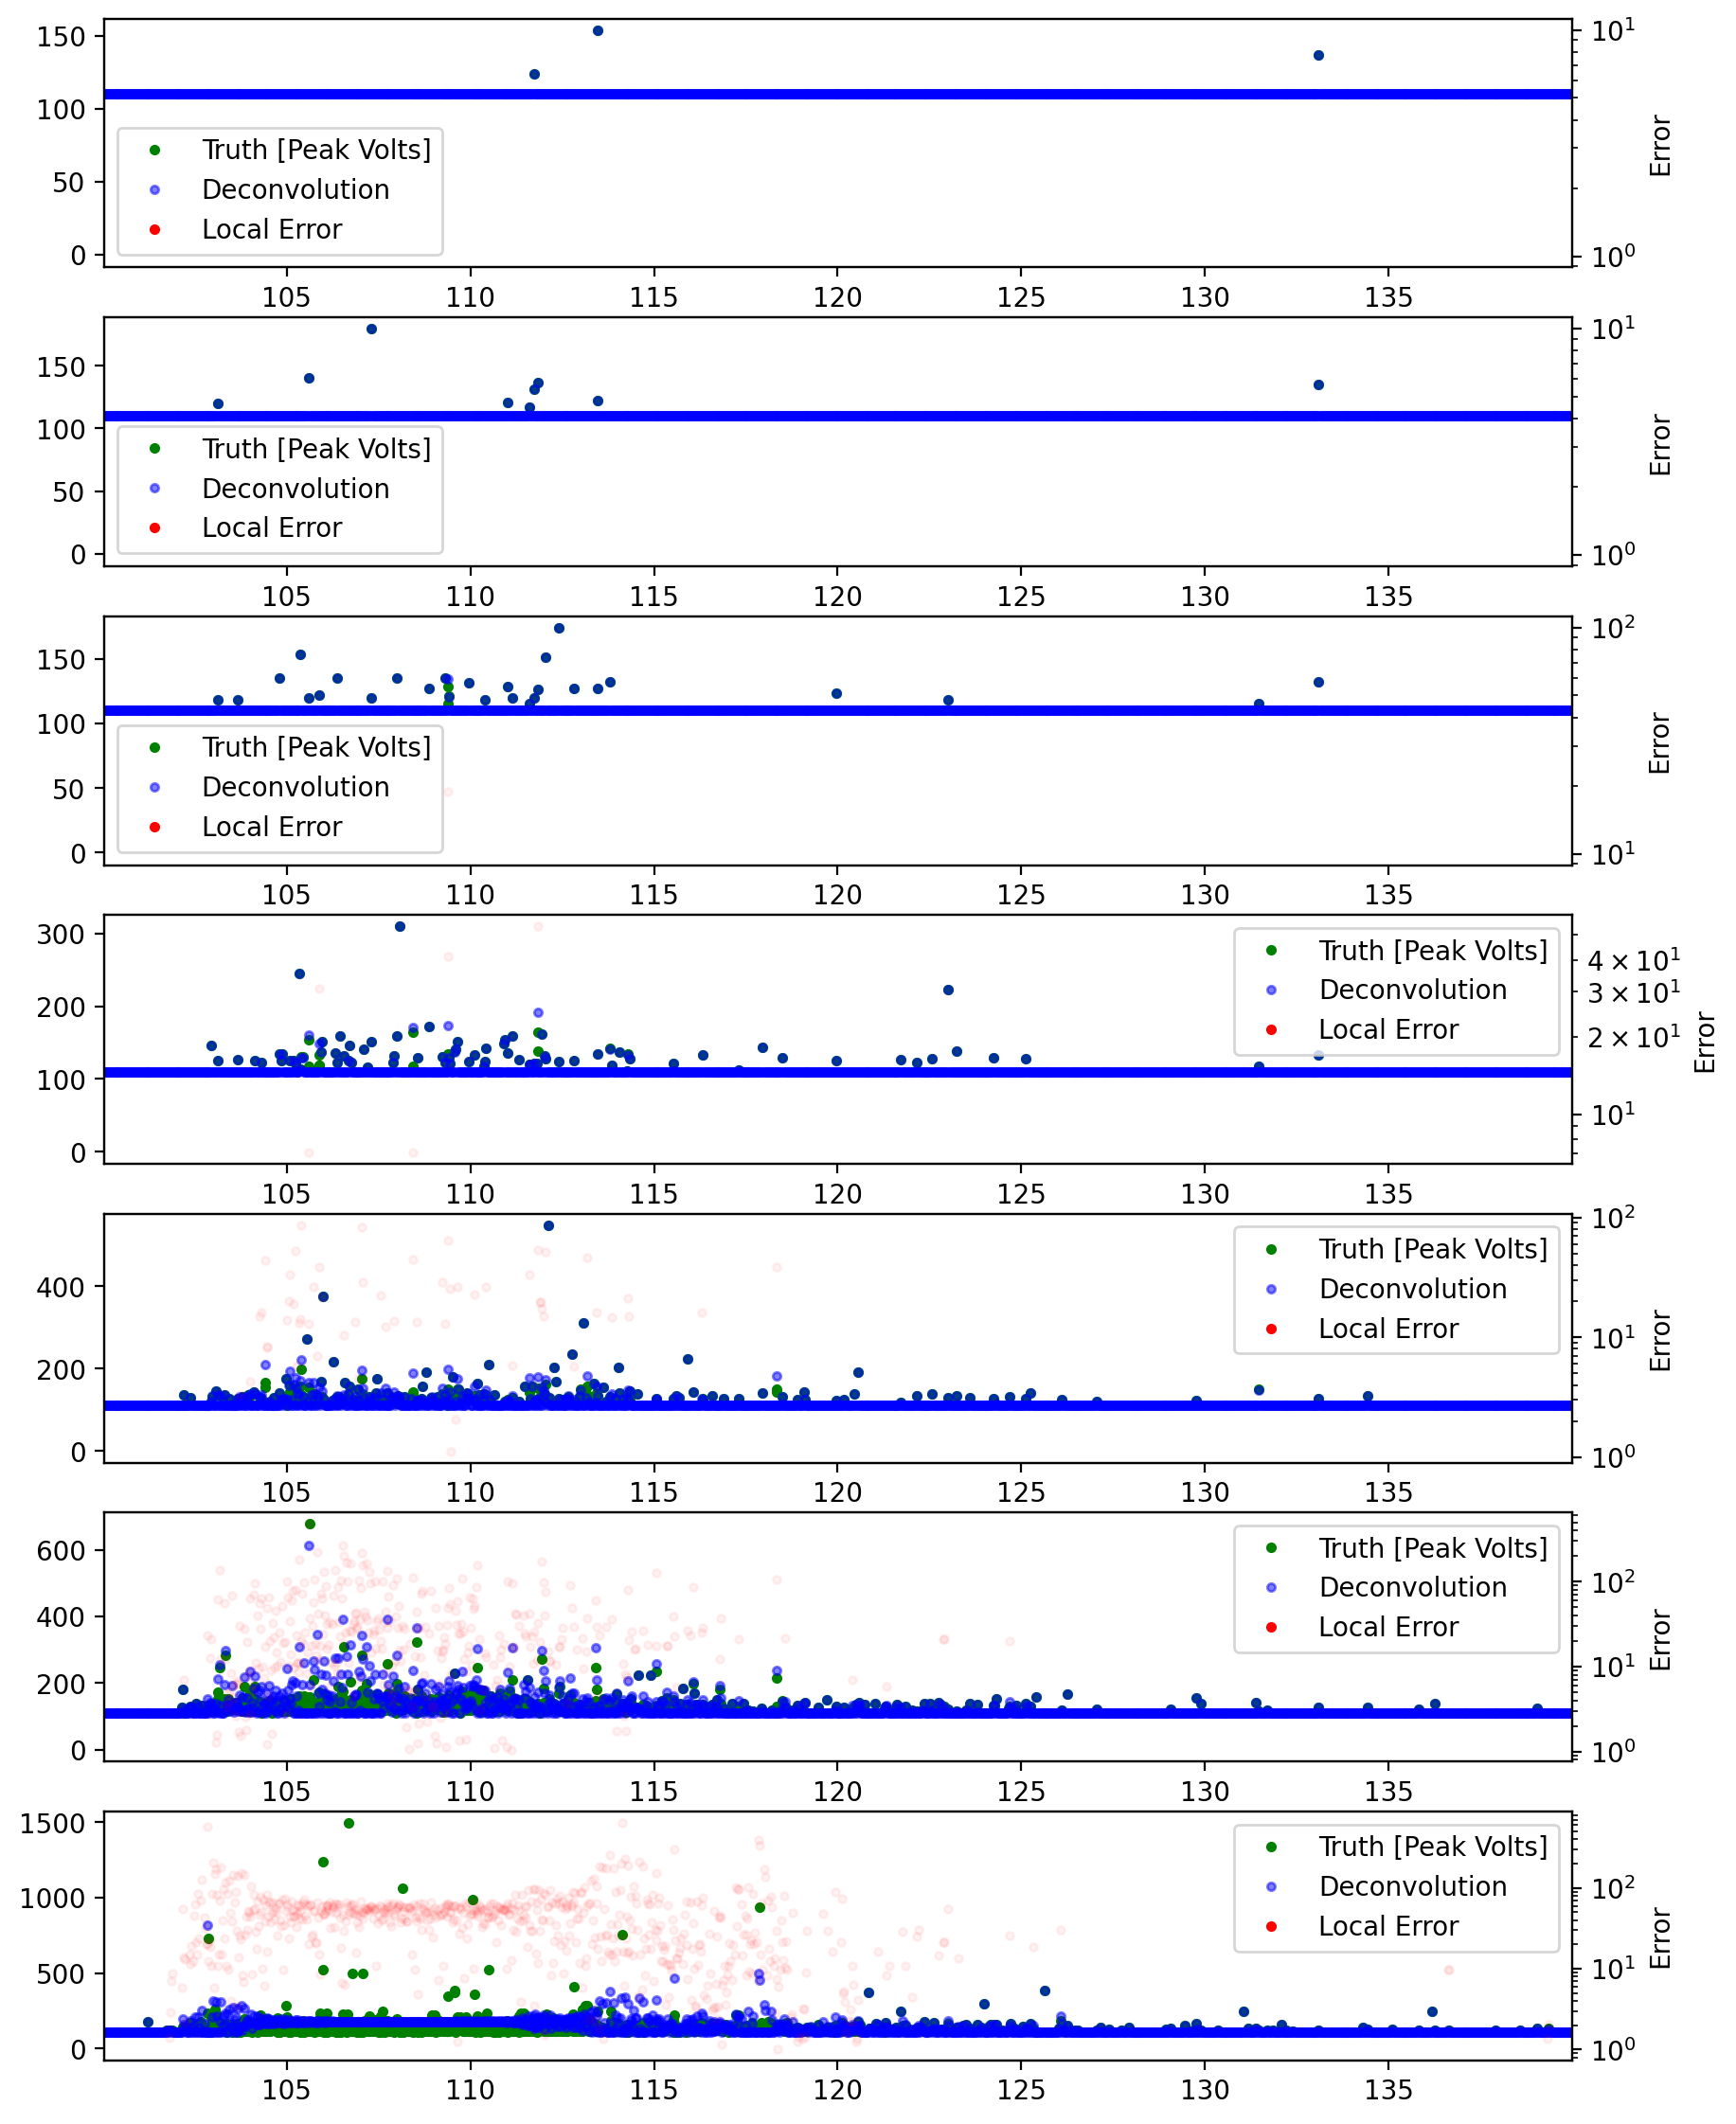

In [31]:
# Deconvolutions

n = countrates.size
fig, axes = plt.subplots(n, 1, figsize=(10, n*2), dpi=200)

for trace_pair, truth_triple, axis  in zip(traces, truth, axes):
    trace_time, trace = trace_pair
    photon_index, energies, peak_volts = truth_triple

    deconv = td_nnlsr_deconvolve(trace - baseline, pulse)
    deconv += baseline

    volts_trace = baseline * np.ones_like(deconv)
    volts_trace[photon_index] = peak_volts
    
    error = np.abs(volts_trace - deconv)
    error_mask = np.where(np.abs(error) > 1)
    
    right = axis.twinx()
    right.plot(trace_time[error_mask], error[error_mask], 'r.', alpha=.05)
    right.set_ylabel('Error')
    right.set_yscale('log')
    
    axis.plot(trace_time[photon_index], peak_volts, 'g.', label='Truth [Peak Volts]')
    axis.plot(trace_time.squeeze(), deconv.squeeze(), 'b.', label='Deconvolution', alpha=.5)
    axis.plot([-1], [-1], 'r.', label='Local Error') # for legend...
    axis.set_xlim(np.min(trace_time), np.max(trace_time))
    axis.legend()

    gc.collect()
    


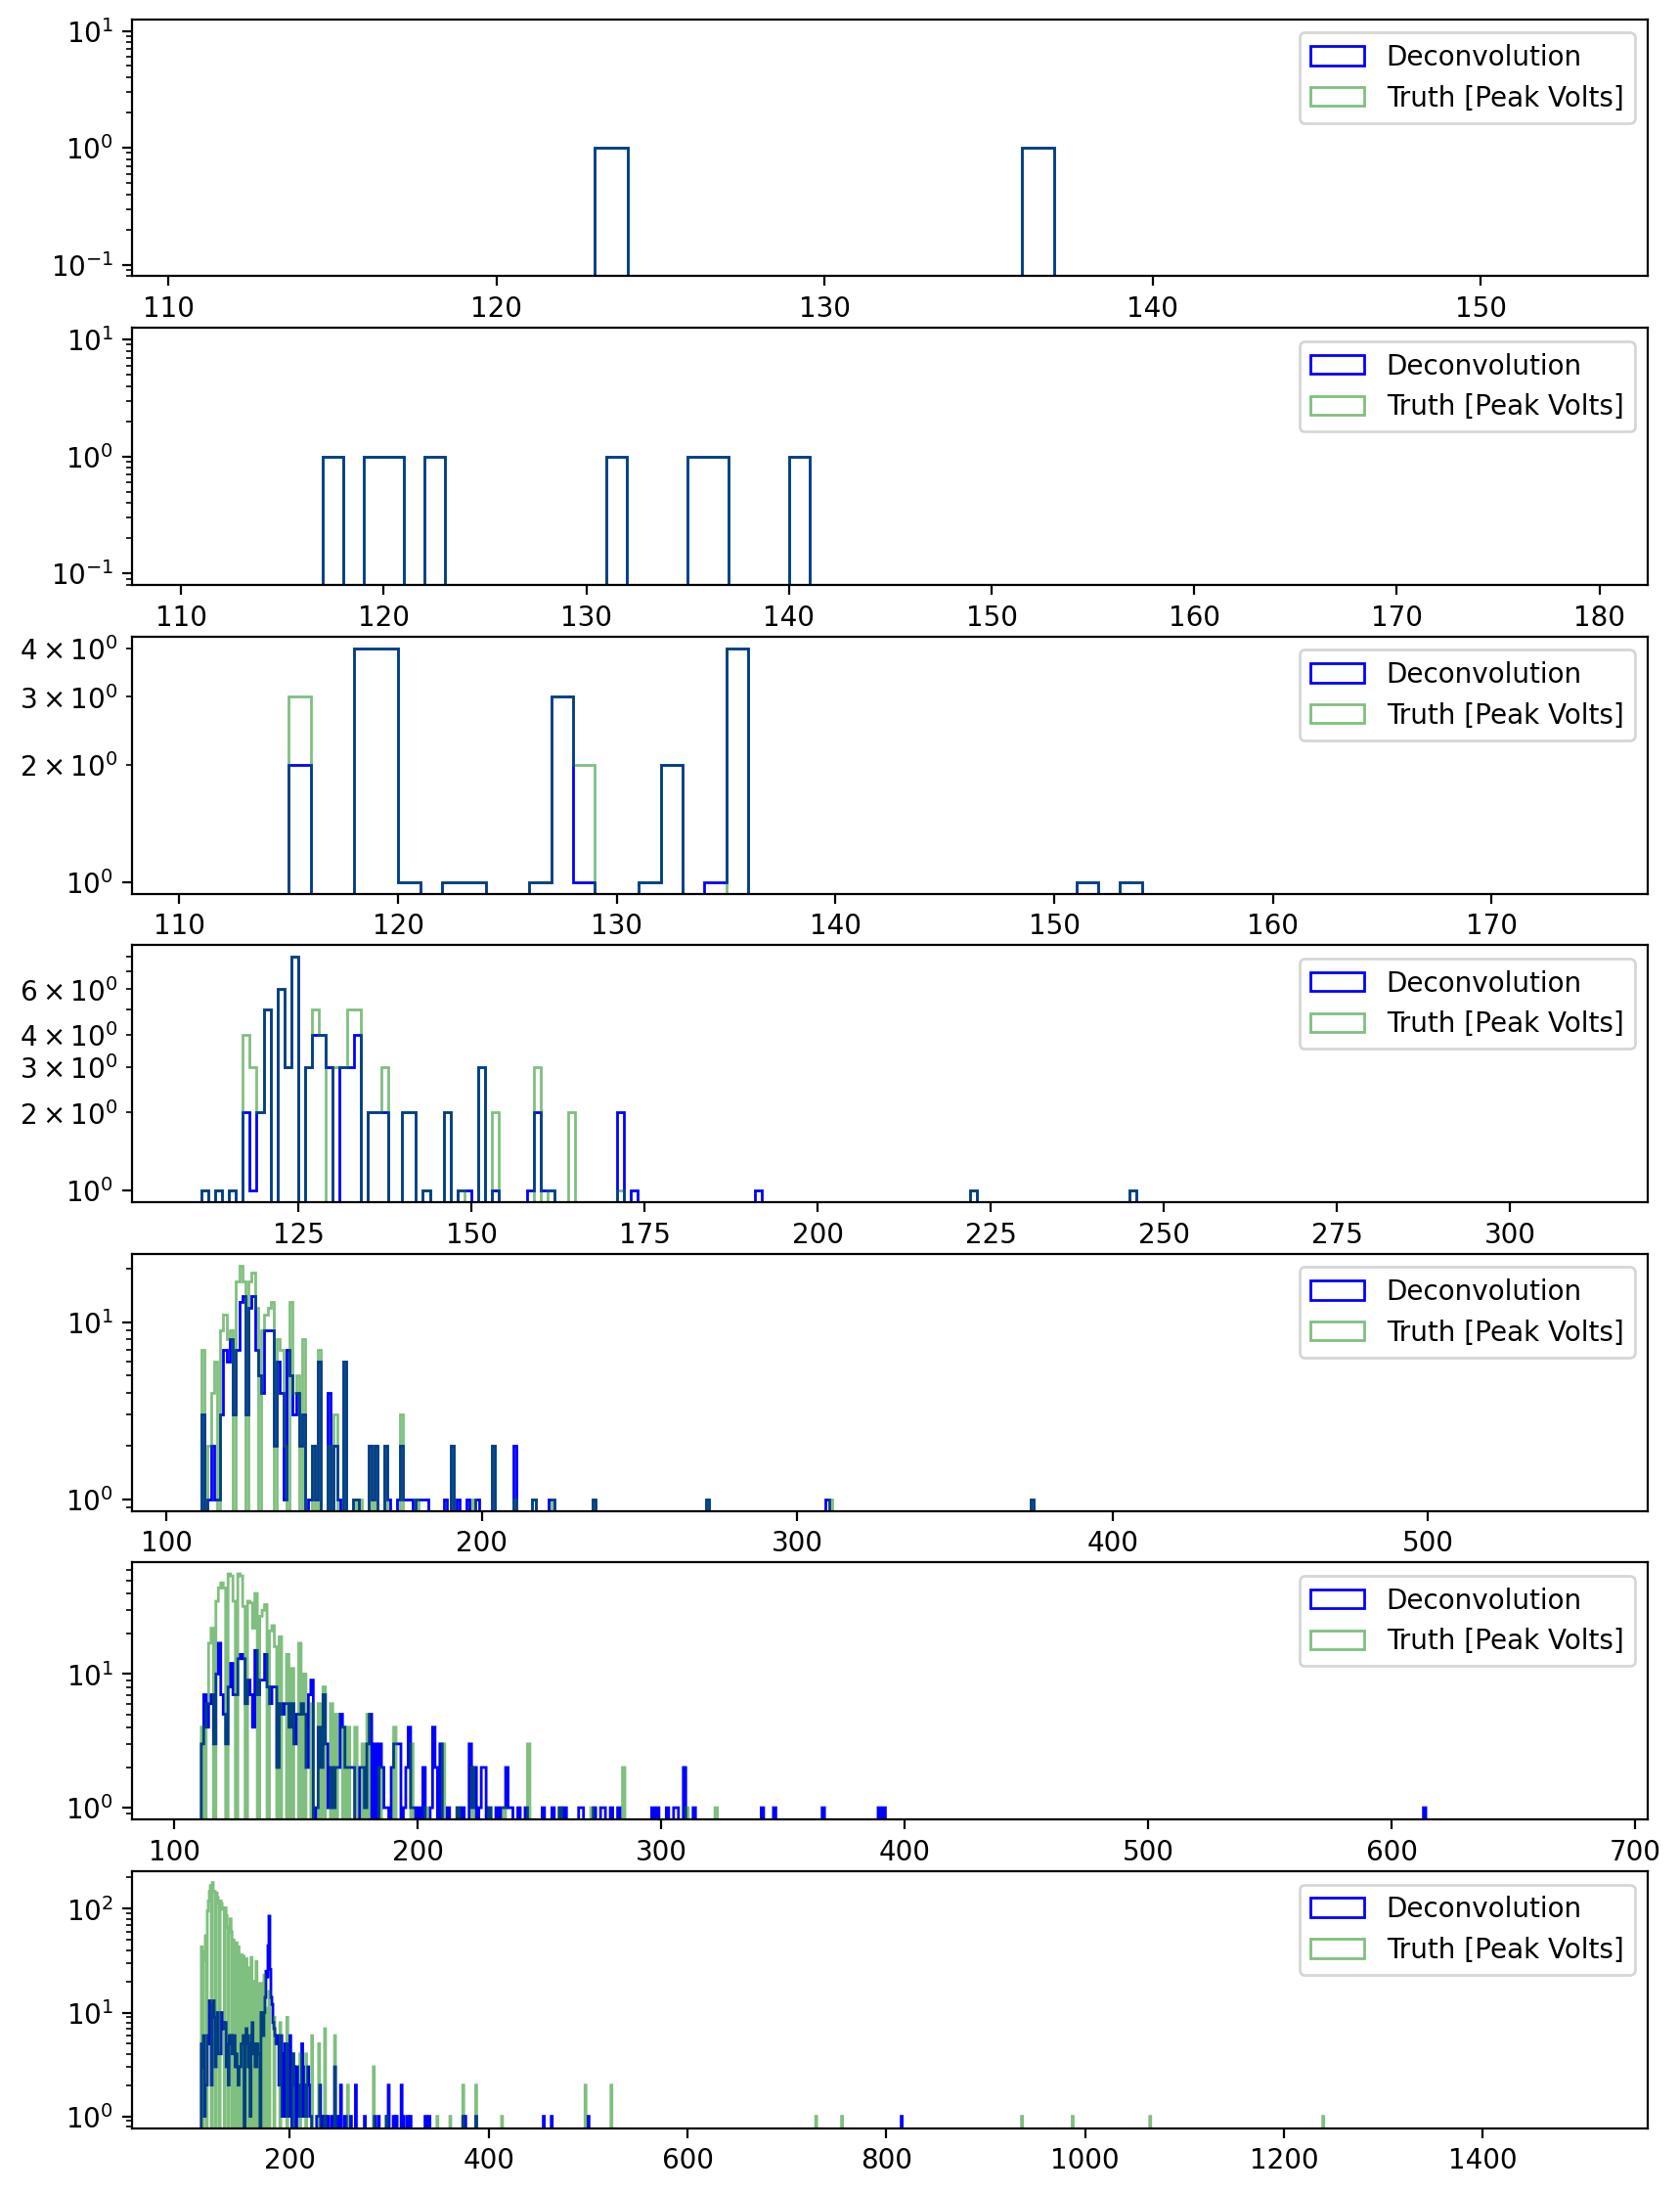

In [32]:
# Error histograms

n = countrates.size
fig, axes = plt.subplots(n, 1, figsize=(10, n*2), dpi=200)

for trace_pair, truth_triple, axis  in zip(traces, truth, axes):
    trace_time, trace = trace_pair
    photon_index, energies, peak_volts = truth_triple

    deconv = td_nnlsr_deconvolve(trace - baseline, pulse)
    deconv += baseline

    volts_trace = baseline * np.ones_like(deconv)
    volts_trace[photon_index] = peak_volts
    
    # deconv_hist, deconv_bin_edges = np.histogram(deconv)
    
    bins = np.arange(baseline+1, max(np.max(peak_volts), np.max(deconv)), 1)
    
    axis.hist(deconv, bins=bins,
              histtype='step',edgecolor='b',linewidth=1,
              log=True,
              density=False,
              label='Deconvolution')
    
    axis.hist(peak_volts, bins=bins,
              histtype='step',edgecolor='g',linewidth=1, alpha=.5,
              log=True,
              density=False,
              label='Truth [Peak Volts]')
    
    axis.legend()

    gc.collect()
    
